# Cargando los datos (previamente limpiados)

In [20]:
import numpy as np
import pandas as pd

df=pd.read_csv('Final_DataFrame.csv',index_col=0) # index_col=0 indica que la primera colmna será el índice

# Vista general de los datos

Y correcciones previas

In [21]:
df

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT
0,2022-08-28,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
1,2022-08-28,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
2,2022-08-28,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
3,2022-08-28,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
4,2022-08-28,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,2023-07-03,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
121998,2023-07-03,7501058757630,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISH PODER O2 PRE-LAVADOR BOT.ATOM. 650 ML N...,FABRIC TREATMENT and SANIT,LIQUIDO,PRELAVADOR,FABRIC TREATMENT,ROSA,PRETREAT
121999,2023-07-03,7501058753441,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISH PODER O2 DOYPACK 120 GR 7501058753441,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
122000,2023-07-03,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122002 entries, 0 to 122001
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
 6   MANUFACTURER                 122002 non-null  object 
 7   BRAND                        122002 non-null  object 
 8   ITEM_DESCRIPTION             122002 non-null  object 
 9   CATEGORY                     122002 non-null  object 
 10  FORMAT                       122002 non-null  object 
 11  ATTR1                        122002 non-null  object 
 12  ATTR2                        122002 non-null  object 
 13  ATTR

Véase que la columna "WEEK" no se cargó en formato de fecha (dtype='object'), por lo que se cambiará a formato de fecha para poder hacer una mejor visualización de datos referente a este parámetro

In [23]:
df['WEEK'] = pd.to_datetime(df['WEEK']) #Cambiamos solo la columna 'WEEK' a formato de decha (datetime)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122002 entries, 0 to 122001
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   WEEK                         122002 non-null  datetime64[ns]
 1   ITEM_CODE                    122002 non-null  object        
 2   TOTAL_UNIT_SALES             122002 non-null  float64       
 3   TOTAL_VALUE_SALES            122002 non-null  float64       
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64       
 5   REGION                       122002 non-null  object        
 6   MANUFACTURER                 122002 non-null  object        
 7   BRAND                        122002 non-null  object        
 8   ITEM_DESCRIPTION             122002 non-null  object        
 9   CATEGORY                     122002 non-null  object        
 10  FORMAT                       122002 non-null  object        
 11  ATTR1                        12

# Identificar las variables clave para el análisis

Una de las preguntas de la empresa es si sus marcas Vanish y Lysol están teniendo un buen desempeño, por lo que será importante comparar entre diferentes marcas (columna 'BRAND')

In [24]:
df['BRAND'].unique() #Con .unique(), podemos ver cuáles son las diferentes categorías que aparecen en esta columna

array(['VANISH', 'SHOUT', 'LA VALENCIANA', 'LOS PATITOS', 'OXI CLEAN',
       'CLARASOL', 'CLOROX', 'DR.BECKMANN', 'CLORALEX',
       'CUELLOS PUNOS Y MANCHITAS', 'BANDERA', 'BCLORHADA', 'PURO SOL',
       'OTHERS MARCA UNIF.', 'TIDE', 'LYSOL', 'BLANCATEL', 'CLORALUZ',
       'CLORTEX', 'PATITO', 'SANYTOL', 'IBERIA', 'LA JAPONESA', 'HARPIC'],
      dtype=object)

También se pregunta sobre quiénes son los competidores clave en cada segmento (columna 'SEGMENT'), además de que se pregunta si los productos sanitizantes han tenido buen desempeño ('SEGMENT': 'SANITIZER')

In [25]:
df['SEGMENT'].unique() 

array(['POWDER', 'PRETREAT', 'BAR', 'LIQUID & GEL', 'BLEACH', 'SANITIZER',
       'OTHERS'], dtype=object)

Otra variable clave es la región de las ventas, para analizar la demografía y el alcance de los productos (columna 'REGION')

In [26]:
df['REGION'].unique()

array(['TOTAL AUTOS AREA 5', 'TOTAL AUTOS AREA 6',
       'TOTAL AUTOS SCANNING MEXICO', 'TOTAL AUTOS AREA 3',
       'TOTAL AUTOS AREA 2', 'TOTAL AUTOS AREA 1', 'TOTAL AUTOS AREA 4'],
      dtype=object)

Por simplicidad, se cambiará el nombre de las regiones, quitando el 'TOTAL AUTOS' en cada etiqueta

In [27]:
df['REGION']=df['REGION'].replace(['TOTAL AUTOS AREA 1','TOTAL AUTOS AREA 2','TOTAL AUTOS AREA 3','TOTAL AUTOS AREA 4','TOTAL AUTOS AREA 5','TOTAL AUTOS AREA 6','TOTAL AUTOS SCANNING MEXICO'], 
                                  ['AREA 1','AREA 2','AREA 3','AREA 4','AREA 5','AREA 6','SCANNING MEXICO'])
df['REGION'].unique()

array(['AREA 5', 'AREA 6', 'SCANNING MEXICO', 'AREA 3', 'AREA 2',
       'AREA 1', 'AREA 4'], dtype=object)

Todas estas variables, como se ha dicho, serán comparadas con las ventas semanales (columna 'TOTAL_UNIT_AVG_WEEKLY_SALES' y 'WEEK')

Cabe aclarar que, si bien sería analizar la categoría de los productos, parece que no es una variable relevante, pues todos los datos pertenecen a una sola categoría

In [28]:
df['CATEGORY'].unique() 

array(['FABRIC TREATMENT and SANIT'], dtype=object)

Por lo tanto, las variables clave son: 'BRAND', 'SEGMENT', 'REGION', 'TOTAL_UNIT_AVG_WEEKLY_SALES' y 'WEEK'

In [29]:
df_clave=df.copy()
df_clave=df_clave[['BRAND', 'SEGMENT', 'REGION', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'WEEK']]
#renobramos la columna 'TOTAL_UNIT_AVG_WEEKLY_SALES' a un nombre más simple: 'WEEKLY_SALES'
df_clave.rename(columns={'TOTAL_UNIT_AVG_WEEKLY_SALES':'WEEKLY_SALES'}, inplace=True) 
df_clave

,BRAND,SEGMENT,REGION,WEEKLY_SALES,WEEK
0,VANISH,POWDER,AREA 5,1.000,2022-08-28
1,VANISH,POWDER,AREA 5,2.916,2022-08-28
2,VANISH,POWDER,AREA 5,5.171,2022-08-28
3,VANISH,POWDER,AREA 5,1.833,2022-08-28
4,VANISH,POWDER,AREA 5,5.375,2022-08-28
...,...,...,...,...,...
121997,VANISH,POWDER,SCANNING MEXICO,4.000,2023-07-03
121998,VANISH,PRETREAT,SCANNING MEXICO,2.797,2023-07-03
121999,VANISH,POWDER,SCANNING MEXICO,9.102,2023-07-03
122000,VANISH,POWDER,SCANNING MEXICO,22.172,2023-07-03


# Distribución de ventas

Primero, para detectar outliers, se analizarán boxplots divididos en categorías

Empezamos por analizar los boxplots por segmentos

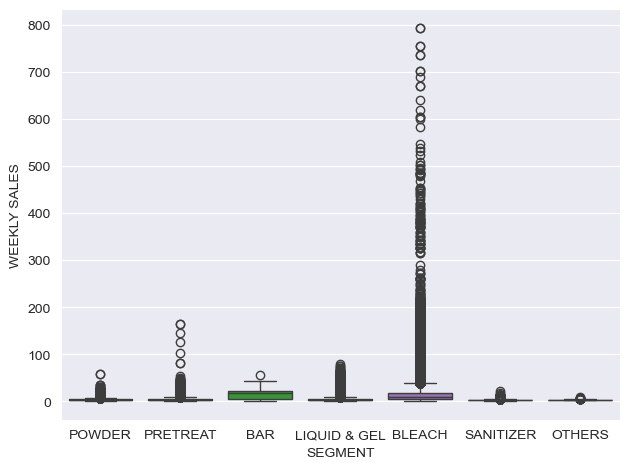

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid') # Seleccionamos un estilo para las gráficas, yo seleccioné el estilo 'darkgrid'

sns.boxplot(df_clave, y='WEEKLY_SALES', x='SEGMENT', hue='SEGMENT')
plt.ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por segmento.png')
plt.show()

El segmento "BLEACH" tiene muchos outliers muy altos, lo que no permite ver claramente los boxplots de los demás segmentos, por lo que se hará un corte en el eje y

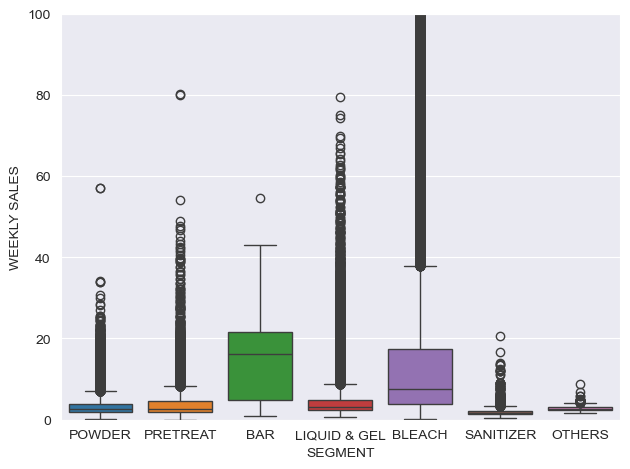

In [31]:
sns.boxplot(df_clave, y='WEEKLY_SALES', x='SEGMENT', hue='SEGMENT')
plt.ylim(0,100)
plt.ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por segmento con zoom.png')
plt.show()

Se puede observar que, mientras que el segmento "BAR" tiene una distribución de ventas bastante consistente, todos los demás cuentan con una cantidad considerable de outliers, en especial los segmentos "BLEACH", "LIQUID & GEL", "PRETREAT" y "POWDER".

Ahora, analizando los boxplots por marca

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\924731335.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


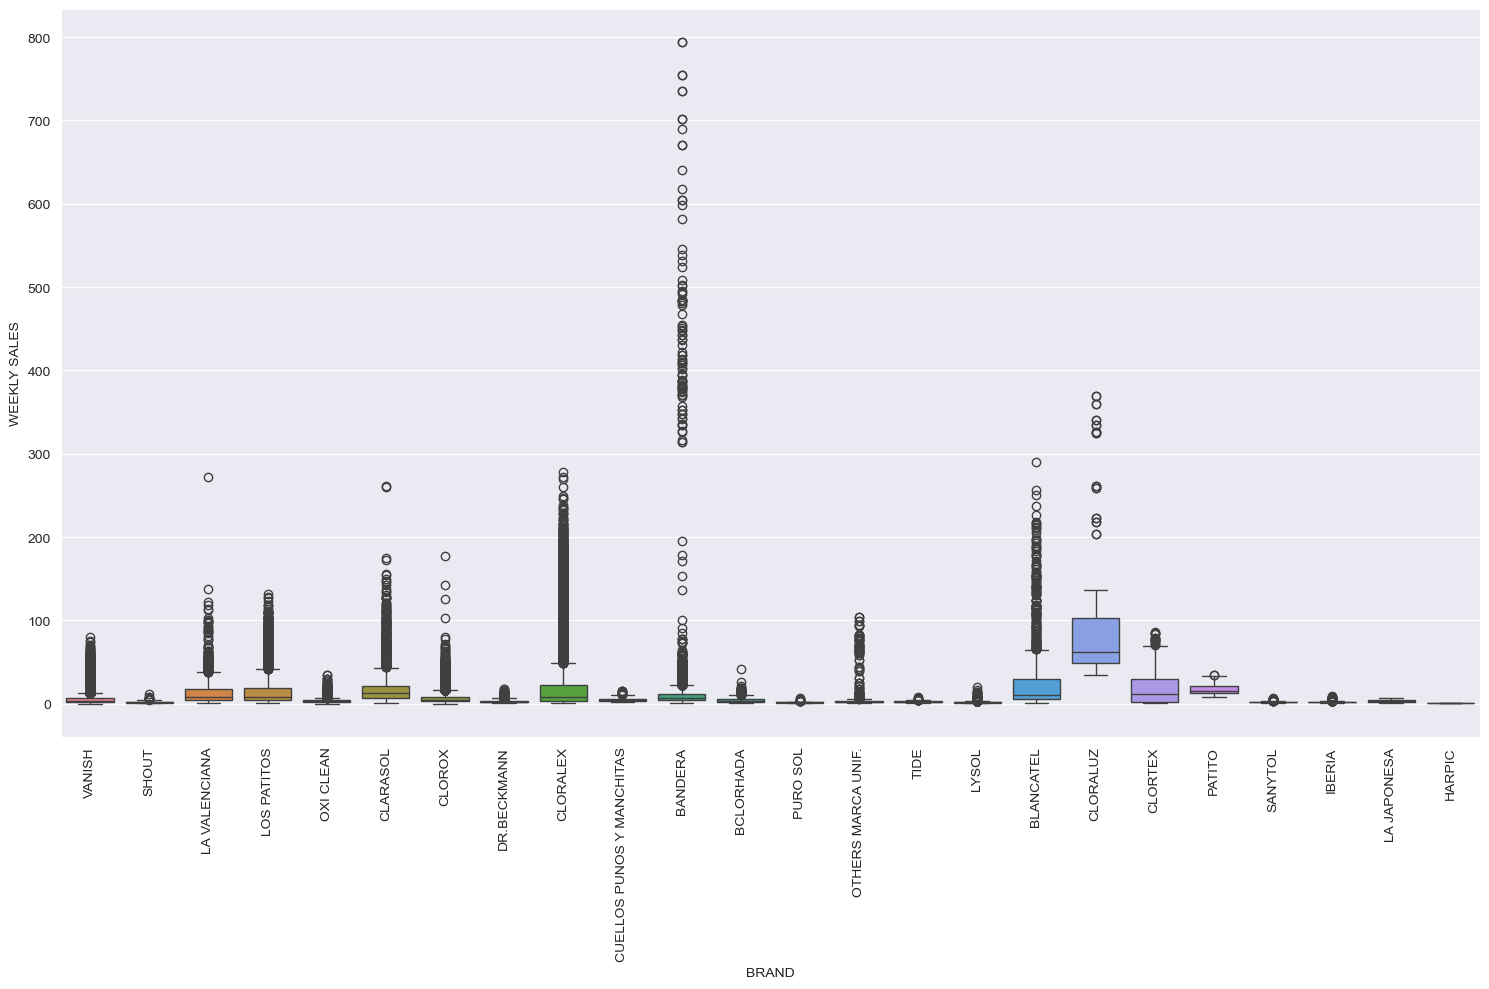

In [32]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(df_clave, y='WEEKLY_SALES', x='BRAND', hue='BRAND', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por marca.png')
plt.show()

Volvemos a hacer un corte en y, dado que los outliers más grandes solo son de una marca

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\921479397.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


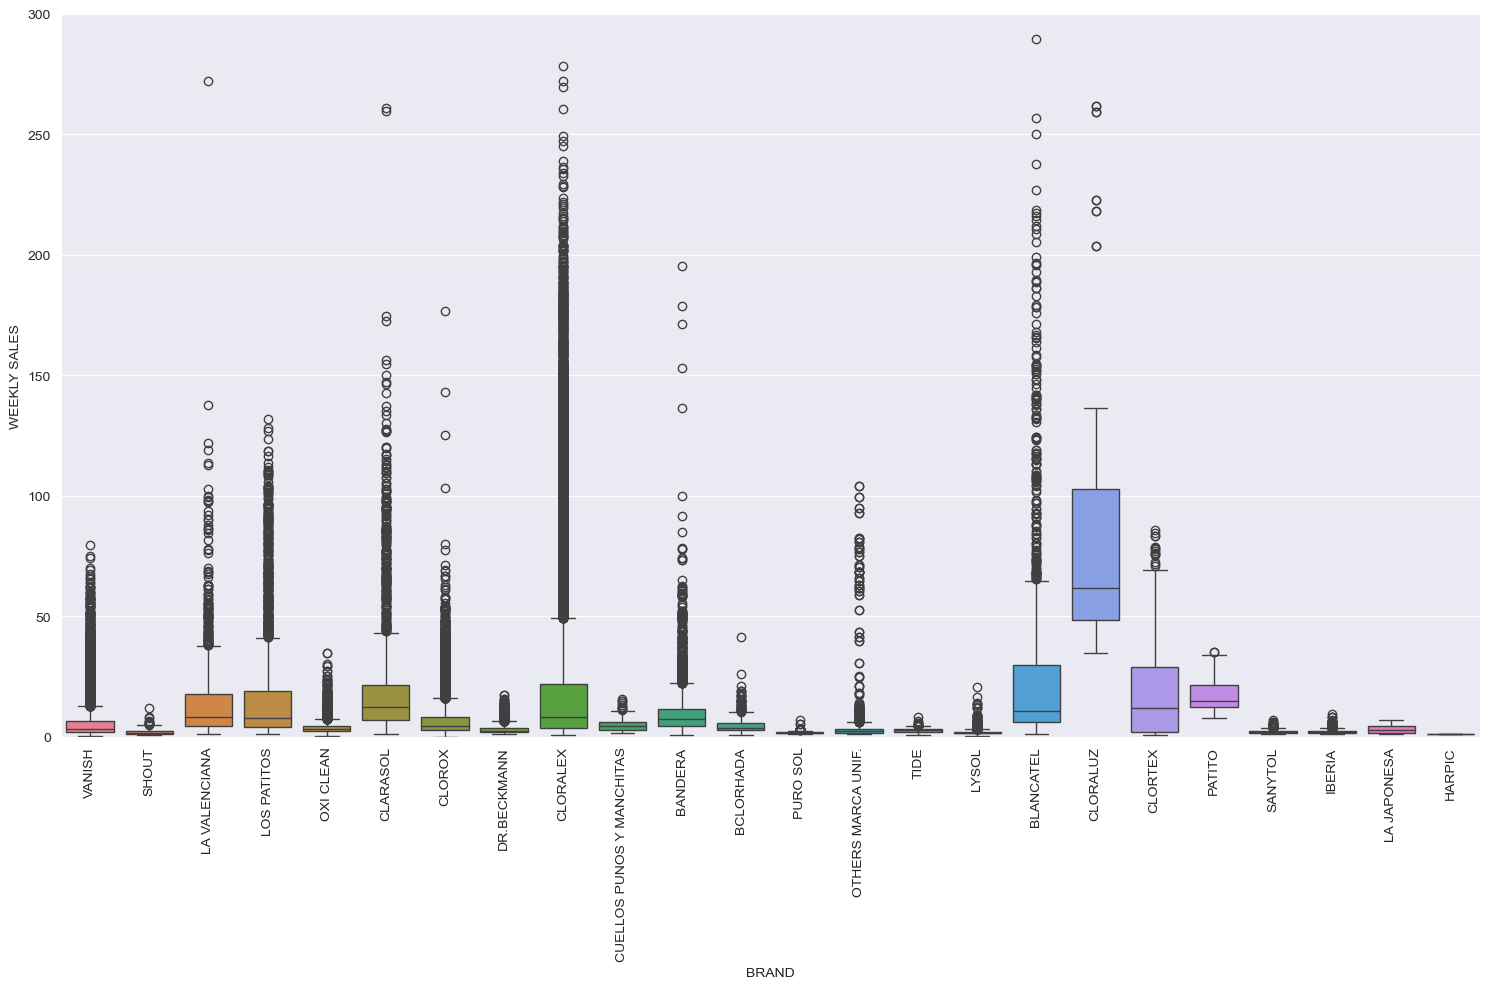

In [33]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(df_clave, y='WEEKLY_SALES', x='BRAND', hue='BRAND', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
ax.set_ylim(0,300)
plt.tight_layout()
plt.savefig('Boxplot por marca con zoom.png')
plt.show()

Se observa que hay marcas con distribuciones consitentes y con pocos outliers como "PATITO", "CLORALUZ" y "LA JAPONESA", en cambio, marcas como "BANDERA", "CLORALEX" Y "BLANCATEL" tienen una gran cantidad de outliers. Además, los outliers más grandes y significativos pertenecen a la marca "BANDERA" y al segmento "BLEACH".

Respecto a las marcas de interés, se observa que "VANISH" cuenta con bastantes outliers grandes y "LYSOL" con outliers pero más pequeños. Desde aquí también se ve que las ventas de estas marcas no son de las mejores en comparación con otras marcas 

# Geografía de las ventas

Analizando ahora las distribuciones por región

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\4169518499.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


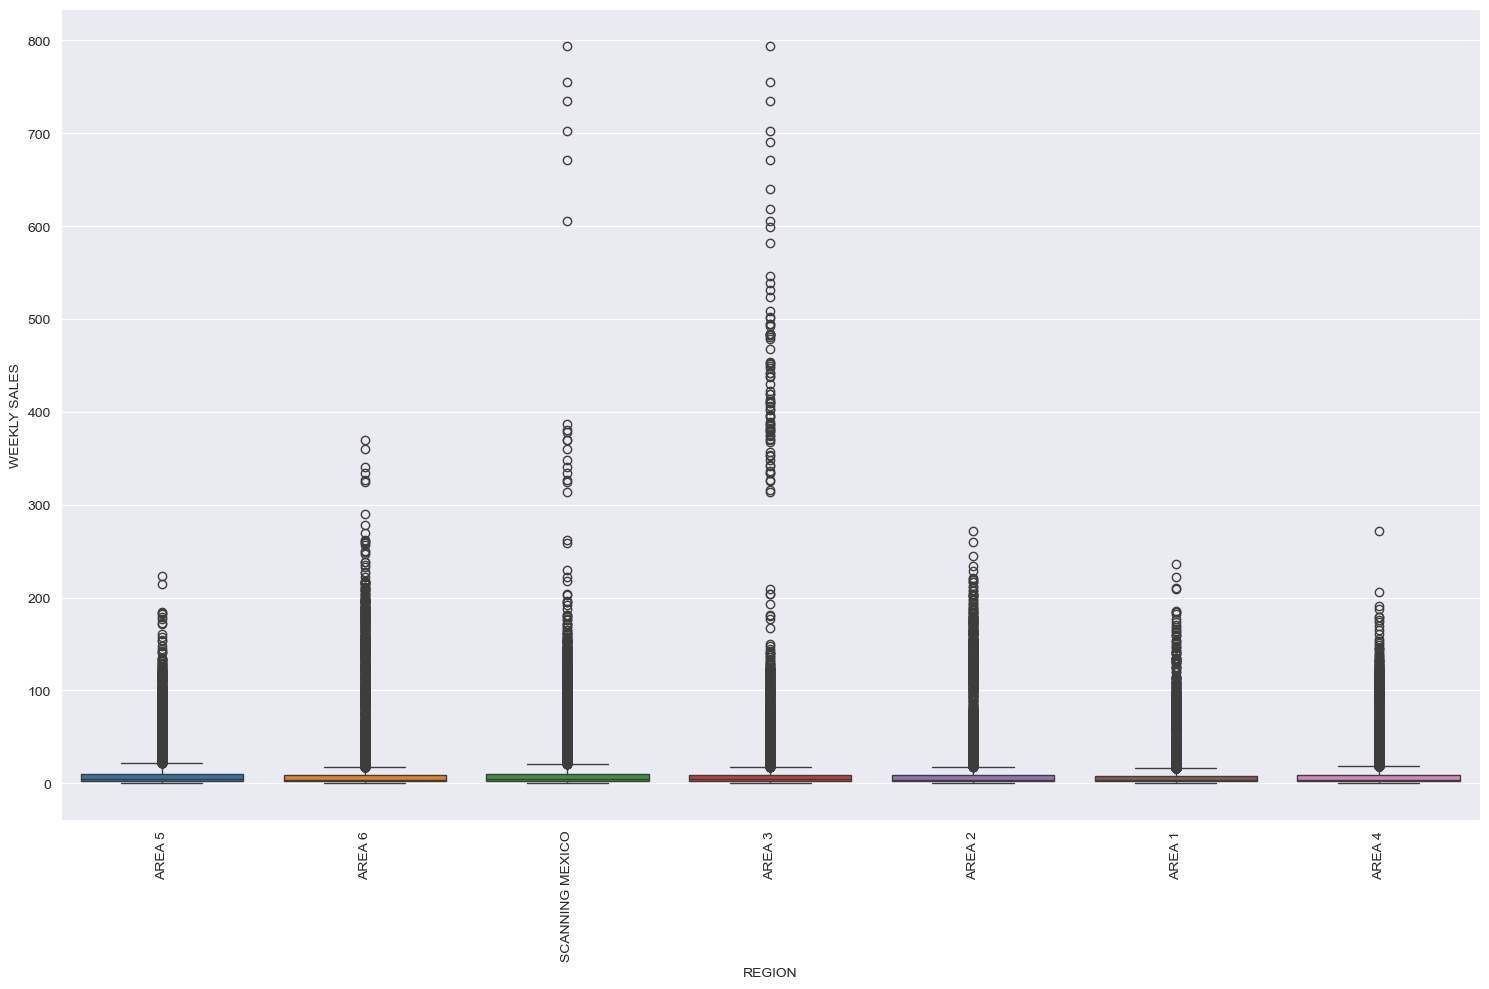

In [34]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(df_clave, y='WEEKLY_SALES', x='REGION', hue='REGION', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.tight_layout()
plt.savefig('Boxplot por region.png')
plt.show()

EN general, las distribuciones de las regiones son muy parecidas, teniendo todas una cantidad considerable de outliers, teniendo el "AREA 3" y "SCANNING MEXICO" los outliers más marcados.

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\4288360709.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


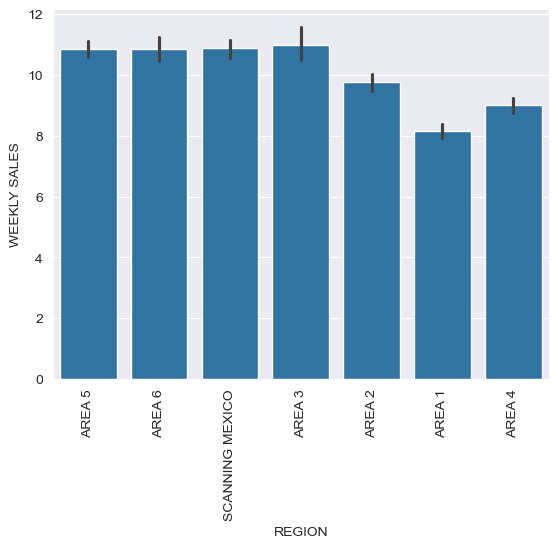

In [35]:
fig, ax = plt.subplots()
sns.barplot(df_clave, x='REGION', y='WEEKLY_SALES', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.savefig('Grafico de barras por region.png')
plt.show()

Al comparar las medianas de las ventas semanales por región (lo ploteado en barplot), se observa que no hay mucha diferencia entre las regiones "AREA 3", "AREA 5", "AREA 6", "SCANNING MEXICO". Las demás regiones tienen ventas ligeramente menores: las regiones "AREA 2", "AREA 4" y "AREA 1", en orden descendente.

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\3109086685.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


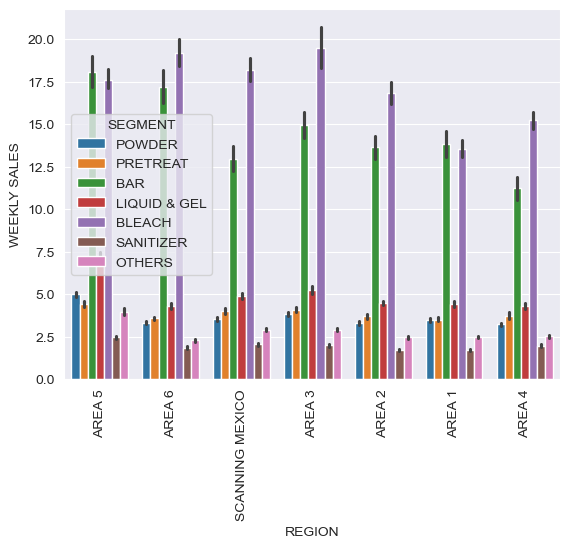

In [36]:
fig, ax = plt.subplots()
sns.barplot(df_clave, x='REGION', y='WEEKLY_SALES', hue='SEGMENT', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.savefig('Grafico de barras por region y segmento.png')
plt.show()

Analizando las distribuciones por región subdivididas por segmento, se observa que los segmentos tienen formas casi iguales en cada región, siendo los "SANITIZER", "OTHERS", "POWDER", "PRETREAT" y "LIQUID & GEL" lossegmenos con menor redimiento (ordenados ascendentemente según ventas semanales en todas las regiones). Los otros dos segmentos "BAR" y "BLEACH" destacan entre los demás por contar con un alto número de ventas, teniendo "BLEACH" las mejores ventas en casi todas las regiones, excepto en el "AREA 5".

# Analizar la tendencia de ventas en el tiempo

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\266350125.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


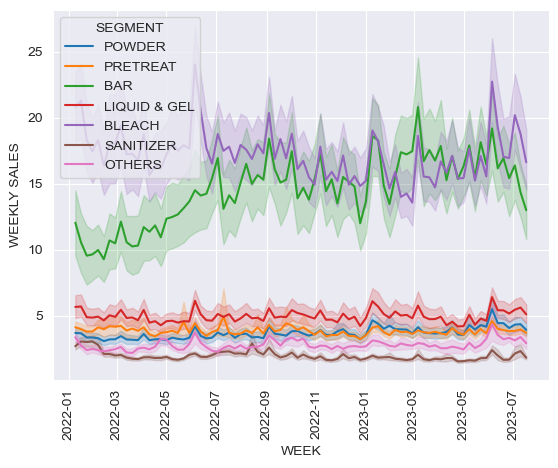

In [37]:
fig, ax = plt.subplots()

sns.lineplot(df_clave, x='WEEK', y='WEEKLY_SALES', hue='SEGMENT', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.savefig('Linea temporal por segmento.png')
plt.show()

Observando la línea de tiempo de las ventas semanales por segmento, se puede ver que lo observado en la figura anterior no fue debido a una época especídica con muy altas ventas, sino que la dominancia de los segmentos "BAR" y "BLEACH" es consistente con el tiempo. Aún así, su margen de error es muy alto en comparación con los demás. "BAR" empezó con bajas ventas en 2022, pero para julio de ese mismo año, sus ventas subieron al punto de competir directamente con "BLEACH", incluso superándolo para inicios de 2023. En cambio, "BLEACH" ha tenido una ligera caída desde 2022, pero en general se ha mantenido constante pero con muchas fluctuaciones. Esto es constrastante con los demás segmentos que cuentan con líneas temporales casi planas y con my pocas fluctuaciones. 

C:\Users\sorak\AppData\Local\Temp\ipykernel_17300\2730473937.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)


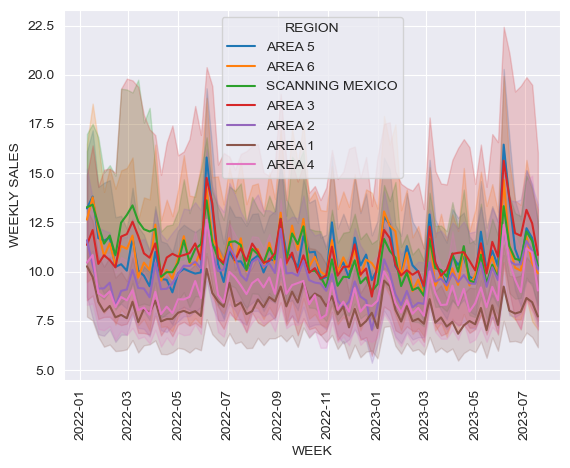

In [38]:
fig, ax = plt.subplots()

sns.lineplot(df_clave, x='WEEK', y='WEEKLY_SALES', hue='REGION', ax=ax)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
ax.set_ylabel('WEEKLY SALES')
plt.show()

Vemos que no hay una diferencia muy clara si clasificamos por regiones a todas las ventas, pero podemos hacer esta división para cada segmento

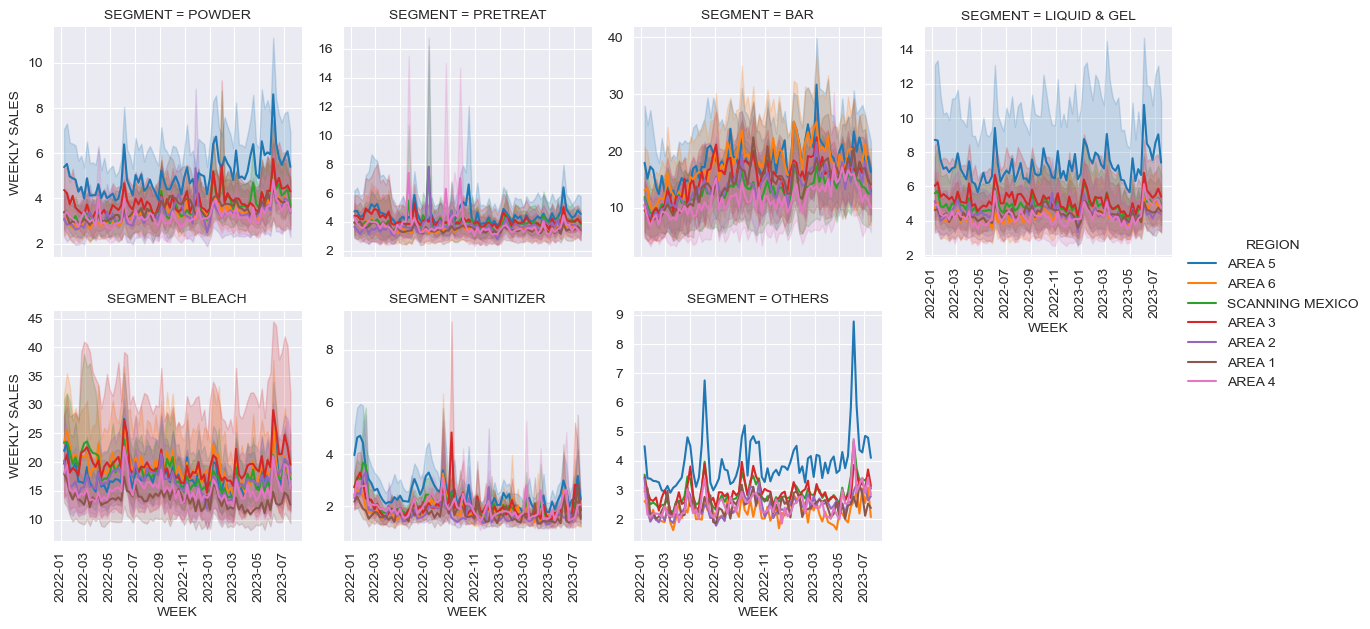

In [39]:
graf=sns.FacetGrid(df_clave, col='SEGMENT', hue='REGION', sharey=False, col_wrap=4)
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES') 

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat] #Comando para rotar 90 grados los xticks labels, dado que son fechas
graf.add_legend()
graf.set_ylabels('WEEKLY SALES')
plt.savefig('Linea temporal por segmento y por region.png')
plt.show()

Anteriormente se observó que no había una región que destacara sobre las otras, pero aquí, se nota que el "AREA 5" cuenta con una dominancia clara en segmentos como "POWDER", "LIQUID & GEL", "SANITIZER" y "OTHERS". Dado que la empresa Reckitt está interesada en el rendimiento de los sanitizantes, una buena sugerencia sería aumentar la cantidad de productos en venta en esta región. Para este segmento, las otras regiones que destacan son el "AREA 4", que sobresale en ciertas épocas con varios picos de ventas, y el "AREA 3" que en general se mantiene bajo a excepción del pico enrome que hubo en septiembre de 2022. 

Cabe destacar que los ejes 'y' de cada gráfica son diferentes, por lo que no se puede comparar en esta figura las ventas entre cada segmento.

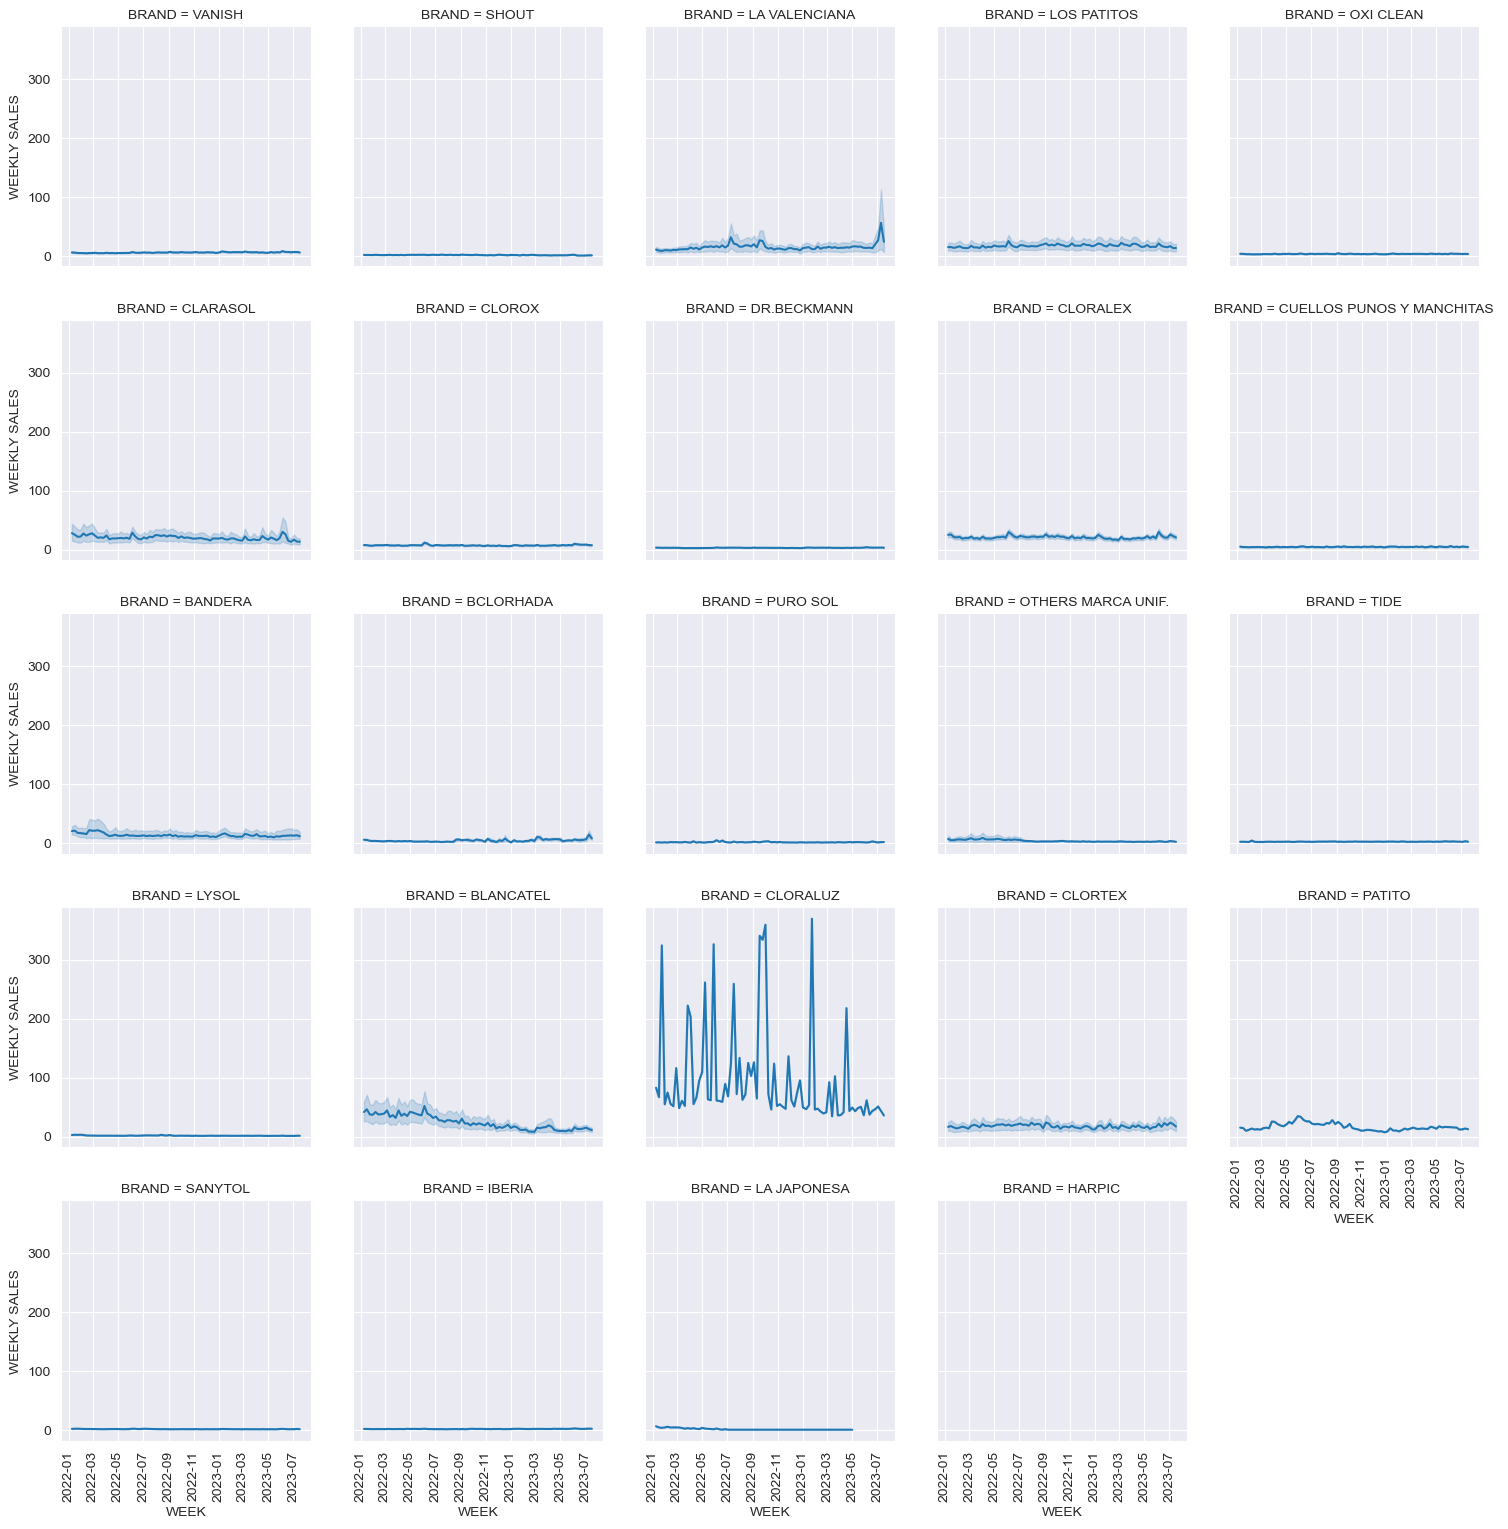

In [168]:
graf=sns.FacetGrid(df_clave, col='BRAND', col_wrap=5) 
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES') 

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat]

graf.set_ylabels('WEEKLY SALES')
graf.add_legend()
plt.show()

Al intentar comparar las líneas temporales entre marcas, encontramos el problema de que la marca "CLORALUZ" parece tener pocos datos de ventas y demasiado altas, dado que hay un margen de error muy pequeño pero fluctúa demasiado. En la sigiente figura, se eliminará esta marca para que se pueda comparar mejor las demás marcas.

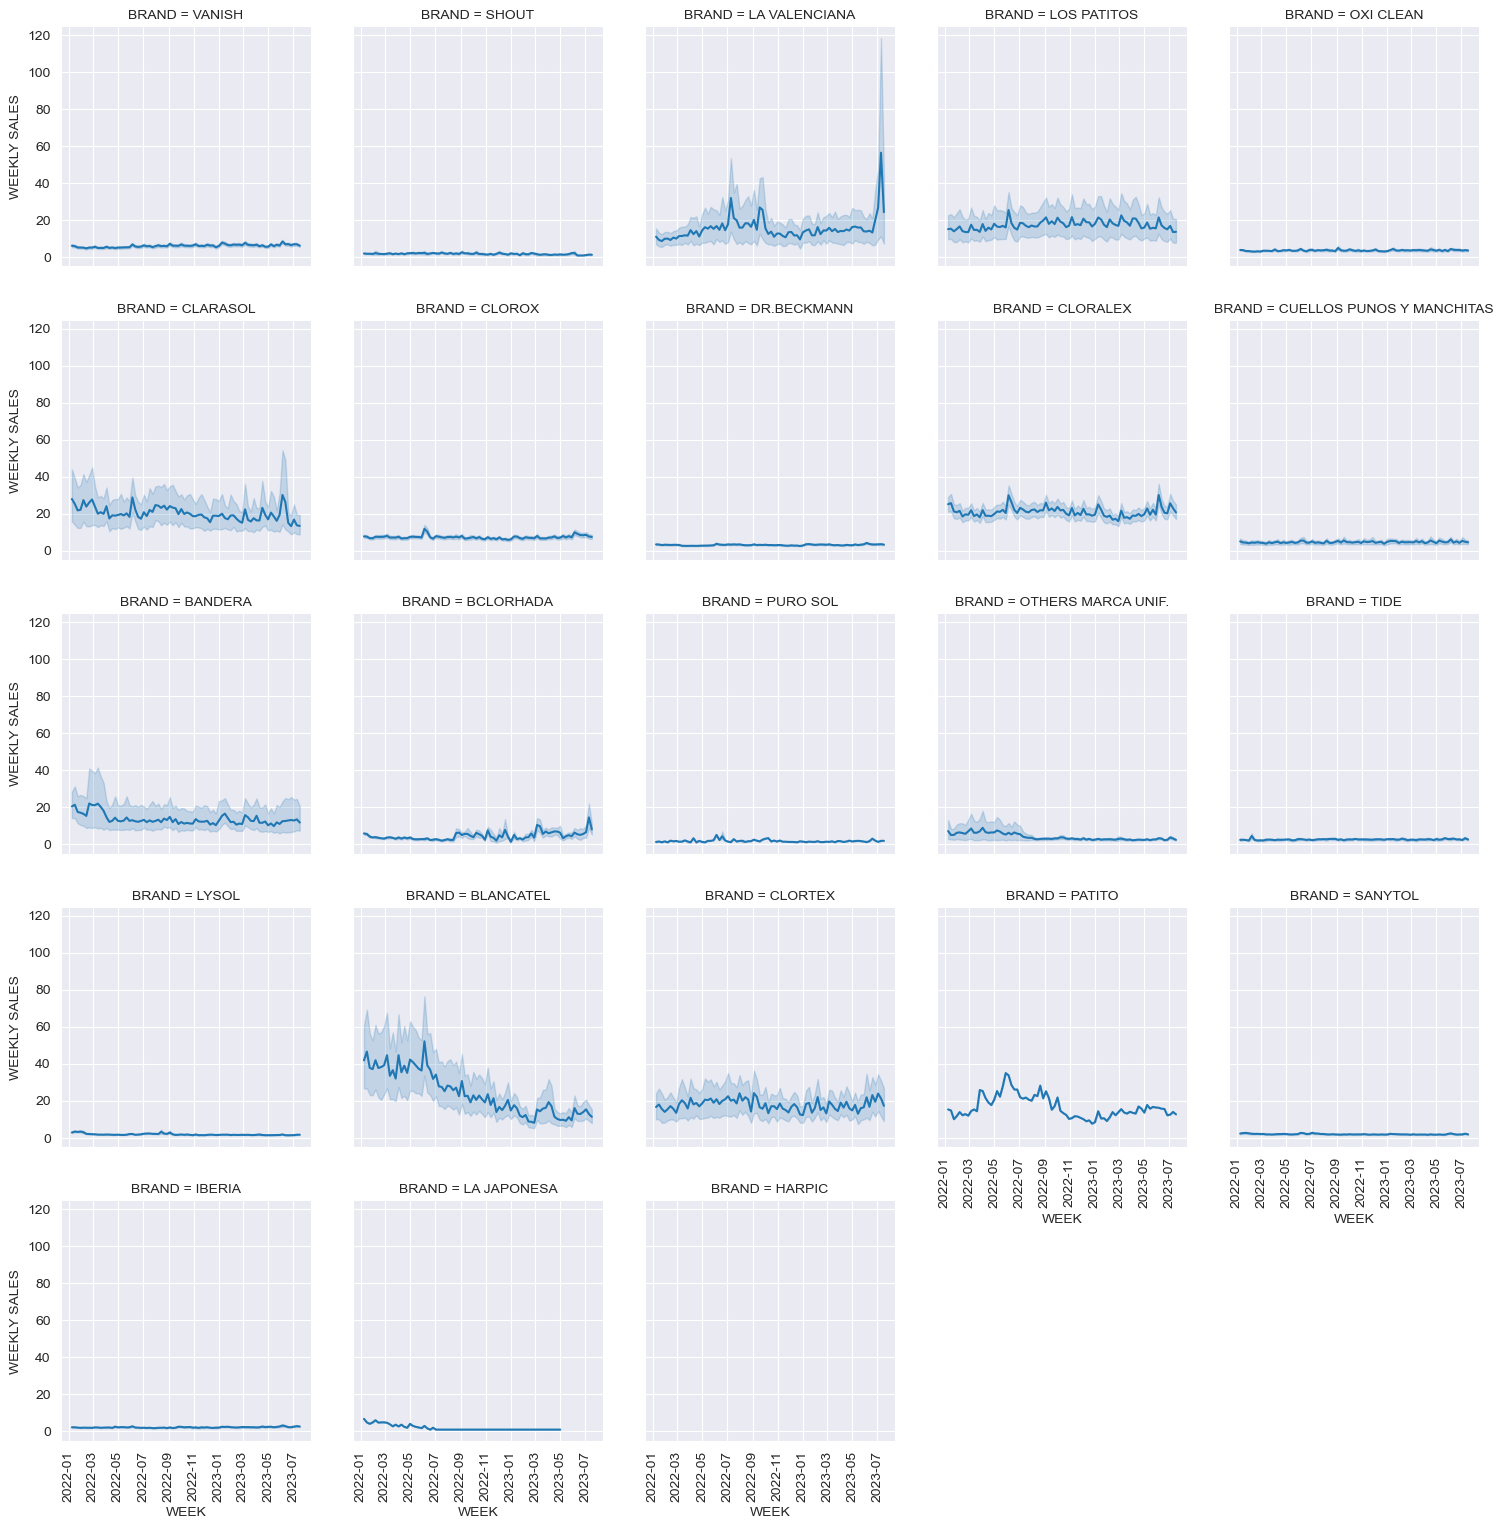

In [41]:
graf=sns.FacetGrid(df_clave[df_clave['BRAND']!='CLORALUZ'], col='BRAND', col_wrap=5) 
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES') 

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat]

graf.set_ylabels('WEEKLY SALES')
graf.add_legend()
plt.savefig('Linea temporal por marca.png')
plt.show()

Observamos que muchas de als marcas presentadas tienen líneas temporales muy planas y cercanas a 0, como lo son lamentablemente, las marcas de "VANISH" y "LYSOL". Pasando a las marcas con mayores ventas, existen algunas que se han mantenido bien en el mercado como "CLORALEX", "BANDERA", "CLORTEX" y "LOS PATITOS", pero hay otras como "BLANCATEL" que han tenido un decrecimiento de ventas conforme pasó el año 2022 y 2023. 

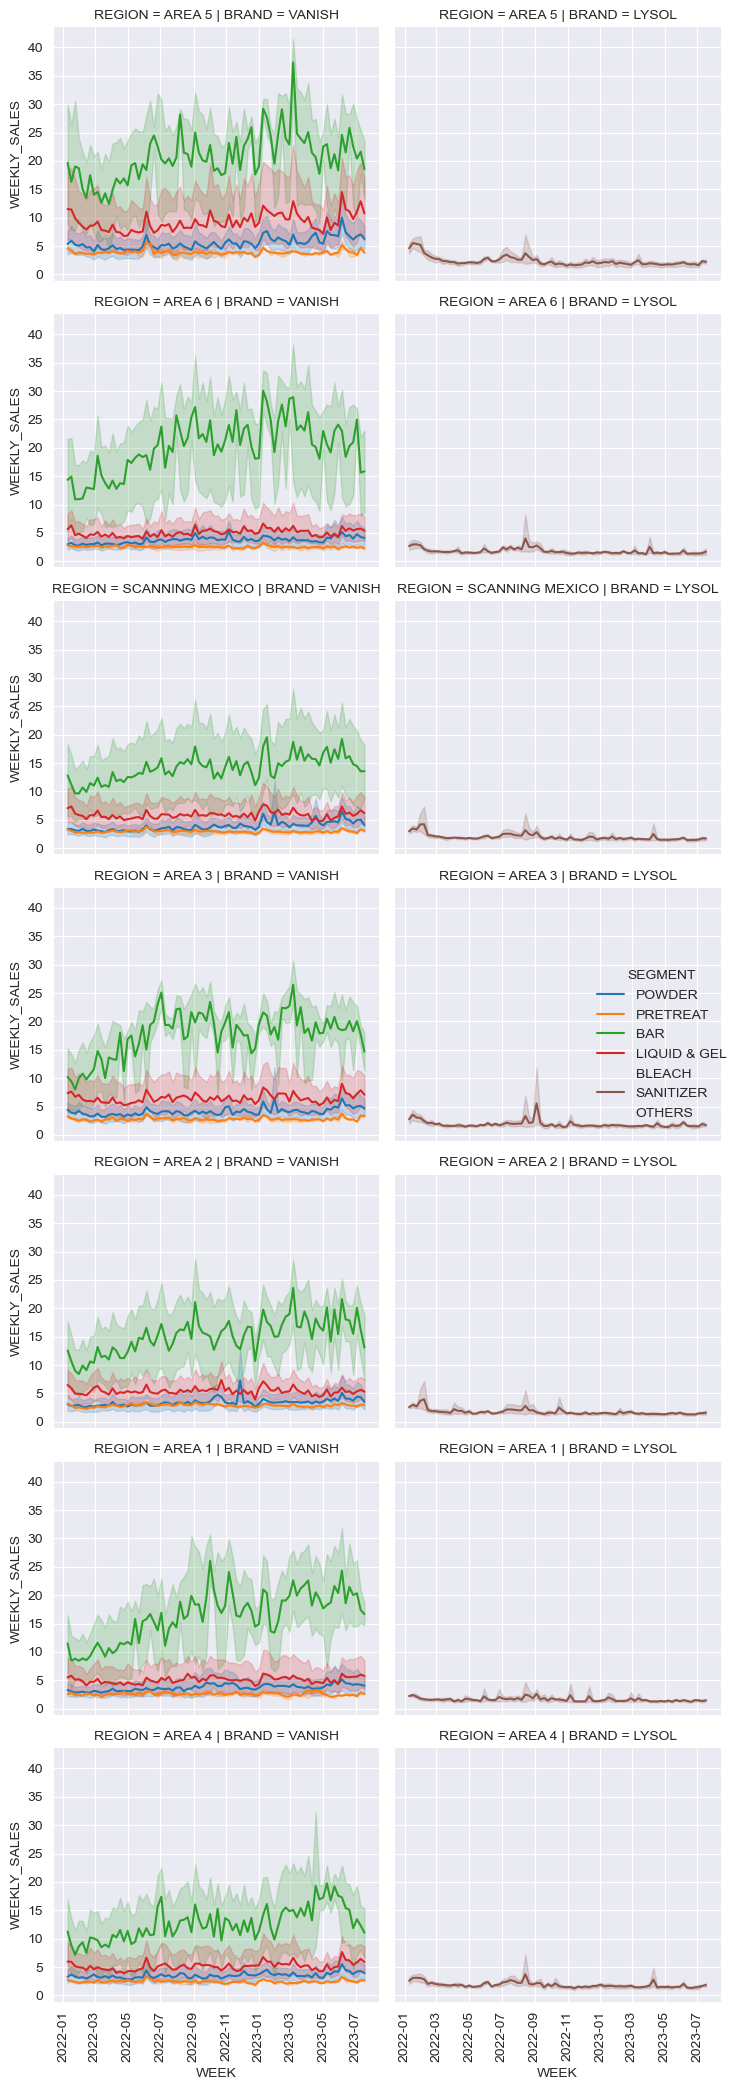

In [ ]:
graf=sns.FacetGrid(df_clave, col='BRAND', row='REGION', col_order=['VANISH', 'LYSOL'], hue='SEGMENT') 
graf.map(sns.lineplot, 'WEEK', 'WEEKLY_SALES') 

[plt.setp(ax.get_xticklabels(), rotation=90) for ax in graf.axes.flat]

graf.set_ylabels('WEEKLY SALES')
graf.add_legend()
plt.tight_layout()
plt.savefig('Linea temporal por segmento y por region para Vanish y Lysol.png')
plt.show()

Haciendo hincapié en las marcas "VANISH" y "LYSOL", se realizó esta gráfica que muestra a detalle las líneas temporales de las ventas de los productos de estas marcas divididas por región y segmento cada una. Podemos ver que "VANISH" realmente ha tenido un muy buen rendimiento en los productos tipo "BAR", sobrepasando en gran medida a los otros segmentos, teniendo además un crecimiento con el paso del tiempo. "LYSOL" presenta un rendimiento muy malo todavía, dado que solo se enuentra en el segmento de "SANITIZER". Comparando entre regiones, se observa que en el "AREA 5" y en el "AREA 6", los productos de "VANISH" tipo "BAR" tienen el mejor rendimiento, pero el mayor núero de fluctuaciones y altos margenes de error, mientras que en la "AREA 3" los margenes de error son menores y cuenta con un crecimiento bastante marcado hasta julio de 2022.